### Load example data (from CSL-SHARE database)

In [1]:
import utils

train_data, y_train, test_data, y_test = utils.get_train_test_data()

print("# Train : ", len(train_data))
print("# Test  : ", len(test_data))
print("Class Labels : ", set(y_train))

# Train :  2095
# Test  :  655
Class Labels :  {'stand-to-sit', 'sit', 'sit-to-stand', 'walk-curve-right', 'walk', 'walk-curve-left', 'stand'}


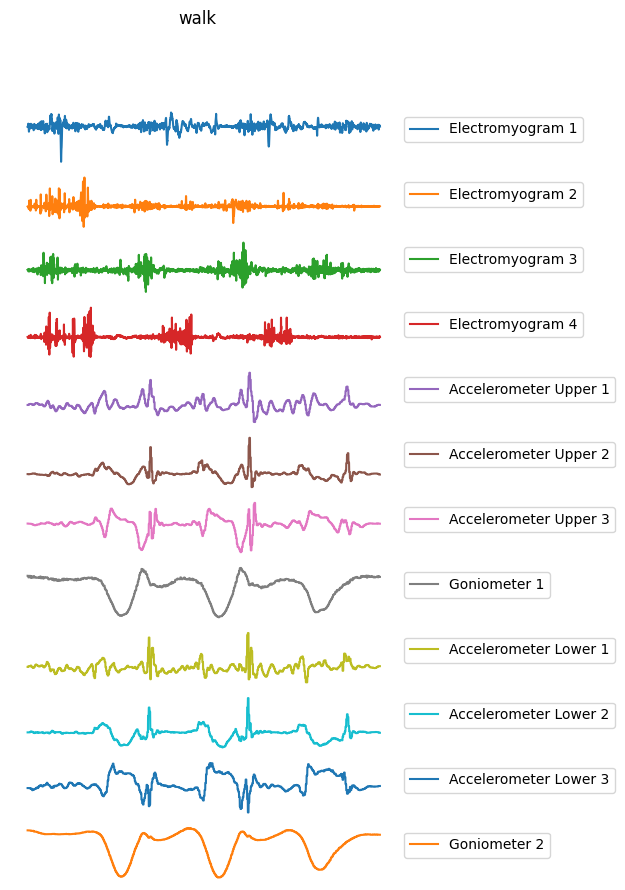

In [2]:
sample, label = utils.plot_random_sample_by_class(train_data, y_train, "walk", ylim=False)


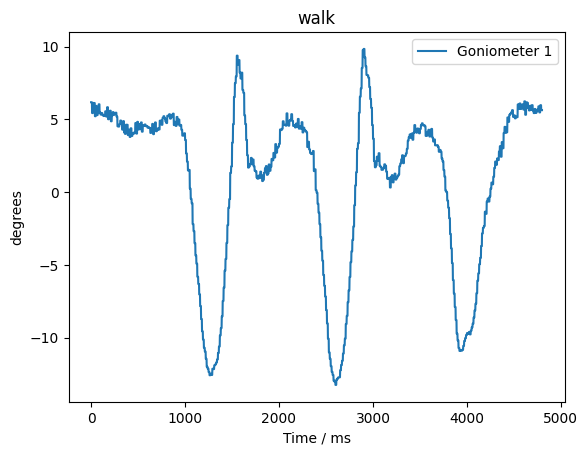

In [3]:
utils.plot_sensor_data(sample, label, "Goniometer 1")

### Feature Extraction with TSFEL

In [4]:
import tsfel

# Create configuration file with statistical features
cfg = tsfel.get_features_by_domain("statistical")

# Extract train and test features 
fs = 1000
X_train = tsfel.time_series_features_extractor(cfg, train_data, fs=fs)
X_test = tsfel.time_series_features_extractor(cfg, test_data, fs=fs)



### Classification with TSFEL

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

# Remove correlated features
correlated_features = tsfel.correlated_features(X_train)
X_train.drop(correlated_features, axis=1, inplace=True)
X_test.drop(correlated_features, axis=1, inplace=True)


# Classification using extracted features from tsfel
clf = RandomForestClassifier(max_depth=5, random_state=1)
clf.fit(X_train, y_train)

y_hat = clf.predict(X_test)

print(f"Accuracy (test) {accuracy_score(y_test, y_hat)}")



ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Accelerometer Lower 1_Average power
- Accelerometer Lower 1_ECDF Percentile Count_1
- Accelerometer Lower 1_ECDF_1
- Accelerometer Lower 1_ECDF_2
- Accelerometer Lower 1_ECDF_3
- ...
